# Pipeline A — Step 2: Panel Fixed Effects OLS

**Model**: LSDV (Least Squares Dummy Variables) — setara Panel FE secara matematis,
tapi menggunakan `sm.OLS` agar prediksi ke tahun baru (OOS) tidak error.

```
twp90_avg_it = alpha_i + gamma_t + beta * X_it + epsilon_it
```

**Input:** `pipeline_A/output/A1_annual_panel.csv`

**Output:** `pipeline_A/output/A2_*.csv` + plot PNG

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

def find_project_root(start: Path) -> Path:
    for p in [start.resolve(), *start.resolve().parents]:
        if (p / 'pipeline_A' / 'output' / 'A1_annual_panel.csv').exists():
            return p
    raise FileNotFoundError('A1_annual_panel.csv not found')

ROOT = find_project_root(Path.cwd())
input_path = ROOT / 'pipeline_A' / 'output' / 'A1_annual_panel.csv'
output_dir = ROOT / 'pipeline_A' / 'output'
output_dir.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(input_path)
print(f'Loaded: {input_path}')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} cols')
print(f'Years: {sorted(df["tahun"].unique())}')
print(f'Provinces: {df["provinsi_id"].nunique()}')

Loaded: C:\Users\bimyu\Documents\Projects\DatathonMETC\pipeline_A\output\A1_annual_panel.csv
Shape: 155 rows x 30 cols
Years: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Provinces: 31


In [2]:
# === Fitur ekonomi ===
econ_cols = ['x1_bi_rate_avg', 'x2_inflasi_avg', 'log_pdrb',
             'x4_tpt', 'x5_internet', 'x8_ldr', 'x9_npl', 'x10_umkm']
needed = econ_cols + ['twp90_avg', 'provinsi_id', 'tahun', 'nama_provinsi']
df_clean = df.dropna(subset=econ_cols + ['twp90_avg']).copy()
print(f'After dropping NaN: {len(df_clean)} rows')

# === LSDV: buat dummies dari SELURUH data (train+test) sebelum split ===
# Ini kunci fix: Patsy-free, jadi predict ke tahun baru tidak error
prov_dummies = pd.get_dummies(df_clean['provinsi_id'].astype(str),
                              prefix='prov', drop_first=True)
year_dummies = pd.get_dummies(df_clean['tahun'].astype(str),
                              prefix='yr', drop_first=True)

X_full = pd.concat([df_clean[econ_cols].reset_index(drop=True),
                    prov_dummies.reset_index(drop=True),
                    year_dummies.reset_index(drop=True)], axis=1)
X_full = sm.add_constant(X_full)
y_full = df_clean['twp90_avg'].reset_index(drop=True)

# Cast semua kolom dummy ke float
X_full = X_full.astype(float)

print(f'Feature matrix shape: {X_full.shape}')
print(f'Province dummies: {prov_dummies.shape[1]} | Year dummies: {year_dummies.shape[1]}')

# === Train/Test split (index-based, setelah reset) ===
df_clean = df_clean.reset_index(drop=True)
train_mask = df_clean['tahun'] <= 2023
test_mask  = df_clean['tahun'] >= 2024

X_train, y_train = X_full[train_mask], y_full[train_mask]
X_test,  y_test  = X_full[test_mask],  y_full[test_mask]

print(f'Train: {train_mask.sum()} obs | Test: {test_mask.sum()} obs')

After dropping NaN: 124 rows
Feature matrix shape: (124, 42)
Province dummies: 30 | Year dummies: 3
Train: 62 obs | Test: 62 obs


In [3]:
# === MODEL 1: Panel FE OLS (LSDV) dengan clustered SE ===
model_fe = sm.OLS(y_train, X_train).fit(
    cov_type='cluster',
    cov_kwds={'groups': df_clean.loc[train_mask, 'provinsi_id'].values}
)
print('=' * 80)
print('MODEL: Panel OLS (LSDV) — Province + Year Fixed Effects')
print('Clustered SE by province')
print('=' * 80)
print(model_fe.summary())

with open(output_dir / 'A2_ols_summary.txt', 'w', encoding='utf-8') as f:
    f.write(str(model_fe.summary()))
print(f'Saved: {output_dir / "A2_ols_summary.txt"}')

MODEL: Panel OLS (LSDV) — Province + Year Fixed Effects
Clustered SE by province
                            OLS Regression Results                            
Dep. Variable:              twp90_avg   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.512
Method:                 Least Squares   F-statistic:                     20.15
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           4.36e-10
Time:                        10:13:08   Log-Likelihood:                 261.59
No. Observations:                  62   AIC:                            -445.2
Df Residuals:                      23   BIC:                            -362.2
Df Model:                          38                                         
Covariance Type:              cluster                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------

Saved: C:\Users\bimyu\Documents\Projects\DatathonMETC\pipeline_A\output\A2_ols_summary.txt


C:\Users\bimyu\AppData\Roaming\Python\Python313\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 41, but rank is 8
  warnings.warn('covariance of constraints does not have full '


In [4]:
# === VIF Check (hanya fitur ekonomi kontinu) ===
vif_data = sm.add_constant(df_clean.loc[train_mask, econ_cols].astype(float))
vif_results = pd.DataFrame({
    'feature': vif_data.columns,
    'VIF': [variance_inflation_factor(vif_data.values, i)
            for i in range(vif_data.shape[1])]
}).sort_values('VIF', ascending=False)

print('=== VIF (Variance Inflation Factor) ===')
print('VIF > 10 = severe | VIF > 5 = moderate')
display(vif_results)

n_high = (vif_results.loc[vif_results['feature'] != 'const', 'VIF'] > 5).sum()
print(f'\n{"⚠️" if n_high else "✅"} {n_high} feature(s) with VIF > 5')

=== VIF (Variance Inflation Factor) ===


VIF > 10 = severe | VIF > 5 = moderate


,feature,VIF
0,const,1832.346863
1,x1_bi_rate_avg,6.147474
2,x2_inflasi_avg,6.050103
4,x4_tpt,1.611524
5,x5_internet,1.507386
6,x8_ldr,1.432509
3,log_pdrb,1.303862
7,x9_npl,1.255859
8,x10_umkm,1.212084



⚠️ 2 feature(s) with VIF > 5


In [5]:
# === Predictions & Evaluation ===
y_train_pred = model_fe.predict(X_train)
y_test_pred  = model_fe.predict(X_test)   # ✅ Bekerja karena dummies sudah dibuat dari full data

# Naive: province mean dari training
prov_means = df_clean.loc[train_mask].groupby('provinsi_id')['twp90_avg'].mean()
y_naive = df_clean.loc[test_mask, 'provinsi_id'].map(prov_means).values

def calc_metrics(y_true, y_pred, name):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    yt, yp = y_true[mask], y_pred[mask]
    return {'model': name, 'n': int(len(yt)),
            'rmse': np.sqrt(mean_squared_error(yt, yp)),
            'mae':  mean_absolute_error(yt, yp),
            'r2':   r2_score(yt, yp)}

m_train = calc_metrics(y_train, y_train_pred, 'Panel FE OLS (Train)')
m_test  = calc_metrics(y_test,  y_test_pred,  'Panel FE OLS (Test)')
m_naive = calc_metrics(y_test,  y_naive,       'Naive (Province Mean)')

print('=' * 70)
print(f'{"Model":<30} {"RMSE":>9} {"MAE":>9} {"R2":>8} {"N":>5}')
print('-' * 70)
for m in [m_train, m_test, m_naive]:
    print(f'{m["model"]:<30} {m["rmse"]:>9.5f} {m["mae"]:>9.5f} {m["r2"]:>8.4f} {m["n"]:>5}')
print('=' * 70)

beat = m_test['rmse'] < m_naive['rmse']
if beat:
    imp = (m_naive['rmse'] - m_test['rmse']) / m_naive['rmse'] * 100
    print(f'\n✅ Model beats naive baseline by {imp:.1f}%')
else:
    print('\n🔴 Model WORSE than naive baseline')

gap = abs(m_train['rmse'] - m_test['rmse']) / m_test['rmse'] * 100
print(f'Overfitting gap (train-test): {gap:.1f}% {"⚠️" if gap > 30 else "✅"}')

pd.DataFrame([m_train, m_test, m_naive]).to_csv(output_dir / 'A2_metrics.csv', index=False)
print(f'Saved: {output_dir / "A2_metrics.csv"}')

Model                               RMSE       MAE       R2     N
----------------------------------------------------------------------
Panel FE OLS (Train)             0.00356   0.00220   0.8159    62
Panel FE OLS (Test)              0.07836   0.07625 -75.0015    62
Naive (Province Mean)            0.00557   0.00424   0.6154    62

🔴 Model WORSE than naive baseline
Overfitting gap (train-test): 95.5% ⚠️
Saved: C:\Users\bimyu\Documents\Projects\DatathonMETC\pipeline_A\output\A2_metrics.csv


In [6]:
# === Koefisien interpretabel (hanya fitur ekonomi, bukan FE dummies) ===
params    = model_fe.params
pvalues   = model_fe.pvalues
conf_int  = model_fe.conf_int()

econ_feats = [p for p in params.index
              if not p.startswith('prov_') and not p.startswith('yr_') and p != 'const']

coeff_df = pd.DataFrame({
    'feature':         econ_feats,
    'coefficient':     params[econ_feats].values,
    'p_value':         pvalues[econ_feats].values,
    'ci_lower':        conf_int.loc[econ_feats, 0].values,
    'ci_upper':        conf_int.loc[econ_feats, 1].values,
    'significant_5pct': (pvalues[econ_feats] < 0.05).values,
}).sort_values('p_value').reset_index(drop=True)

print('=== Economic Feature Coefficients ===')
display(coeff_df)
coeff_df.to_csv(output_dir / 'A2_coefficients.csv', index=False)
print(f'Saved: {output_dir / "A2_coefficients.csv"}')

=== Economic Feature Coefficients ===


,feature,coefficient,p_value,ci_lower,ci_upper,significant_5pct
0,x2_inflasi_avg,-0.930465,0.418615,-3.185187,1.324256,False
1,x1_bi_rate_avg,-0.038505,0.434612,-0.135096,0.058086,False
2,x9_npl,-0.158519,0.440715,-0.561499,0.244461,False
3,log_pdrb,0.011223,0.473749,-0.019482,0.041928,False
4,x10_umkm,-0.102560,0.484914,-0.390372,0.185252,False
5,x8_ldr,0.024055,0.566434,-0.058182,0.106293,False
6,x5_internet,0.030006,0.587288,-0.078346,0.138357,False
7,x4_tpt,0.001693,0.771080,-0.009713,0.013099,False


Saved: C:\Users\bimyu\Documents\Projects\DatathonMETC\pipeline_A\output\A2_coefficients.csv


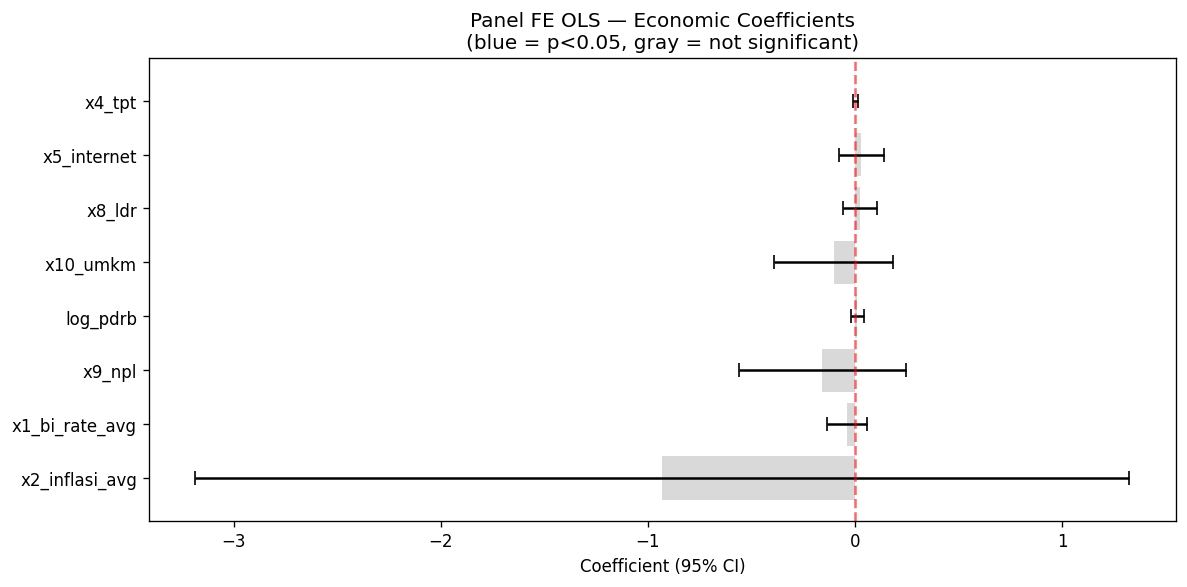

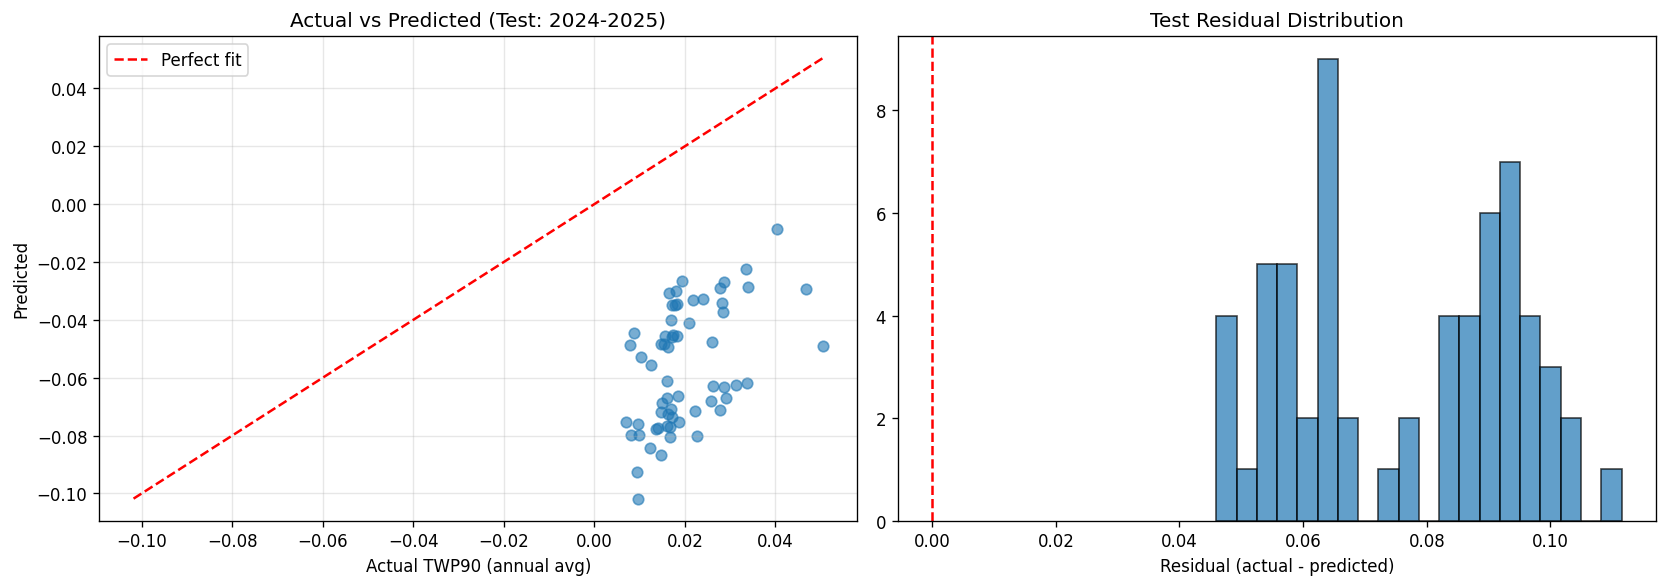

In [7]:
# === VISUALISASI 1: Coefficient Plot ===
fig, ax = plt.subplots(figsize=(10, 5))
y_pos  = range(len(coeff_df))
colors = ['steelblue' if s else 'lightgray' for s in coeff_df['significant_5pct']]
ax.barh(y_pos, coeff_df['coefficient'], color=colors, alpha=0.85)
ax.errorbar(coeff_df['coefficient'], y_pos,
            xerr=[coeff_df['coefficient'] - coeff_df['ci_lower'],
                  coeff_df['ci_upper']    - coeff_df['coefficient']],
            fmt='none', color='black', capsize=4)
ax.axvline(0, color='red', ls='--', alpha=0.6)
ax.set_yticks(y_pos); ax.set_yticklabels(coeff_df['feature'])
ax.set_xlabel('Coefficient (95% CI)')
ax.set_title('Panel FE OLS — Economic Coefficients\n(blue = p<0.05, gray = not significant)')
fig.tight_layout()
fig.savefig(output_dir / 'A2_coefficient_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# === VISUALISASI 2: Actual vs Predicted + Residuals ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

y_test_np = np.array(y_test)
y_test_pred_np = np.array(y_test_pred)

ax = axes[0]
ax.scatter(y_test_np, y_test_pred_np, alpha=0.6, s=40)
lims = [min(y_test_np.min(), y_test_pred_np.min()), max(y_test_np.max(), y_test_pred_np.max())]
ax.plot(lims, lims, 'r--', label='Perfect fit')
ax.set_xlabel('Actual TWP90 (annual avg)'); ax.set_ylabel('Predicted')
ax.set_title('Actual vs Predicted (Test: 2024-2025)')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
residuals = y_test_np - y_test_pred_np
ax.hist(residuals, bins=20, edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', ls='--')
ax.set_title('Test Residual Distribution')
ax.set_xlabel('Residual (actual - predicted)')

fig.tight_layout()
fig.savefig(output_dir / 'A2_prediction_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

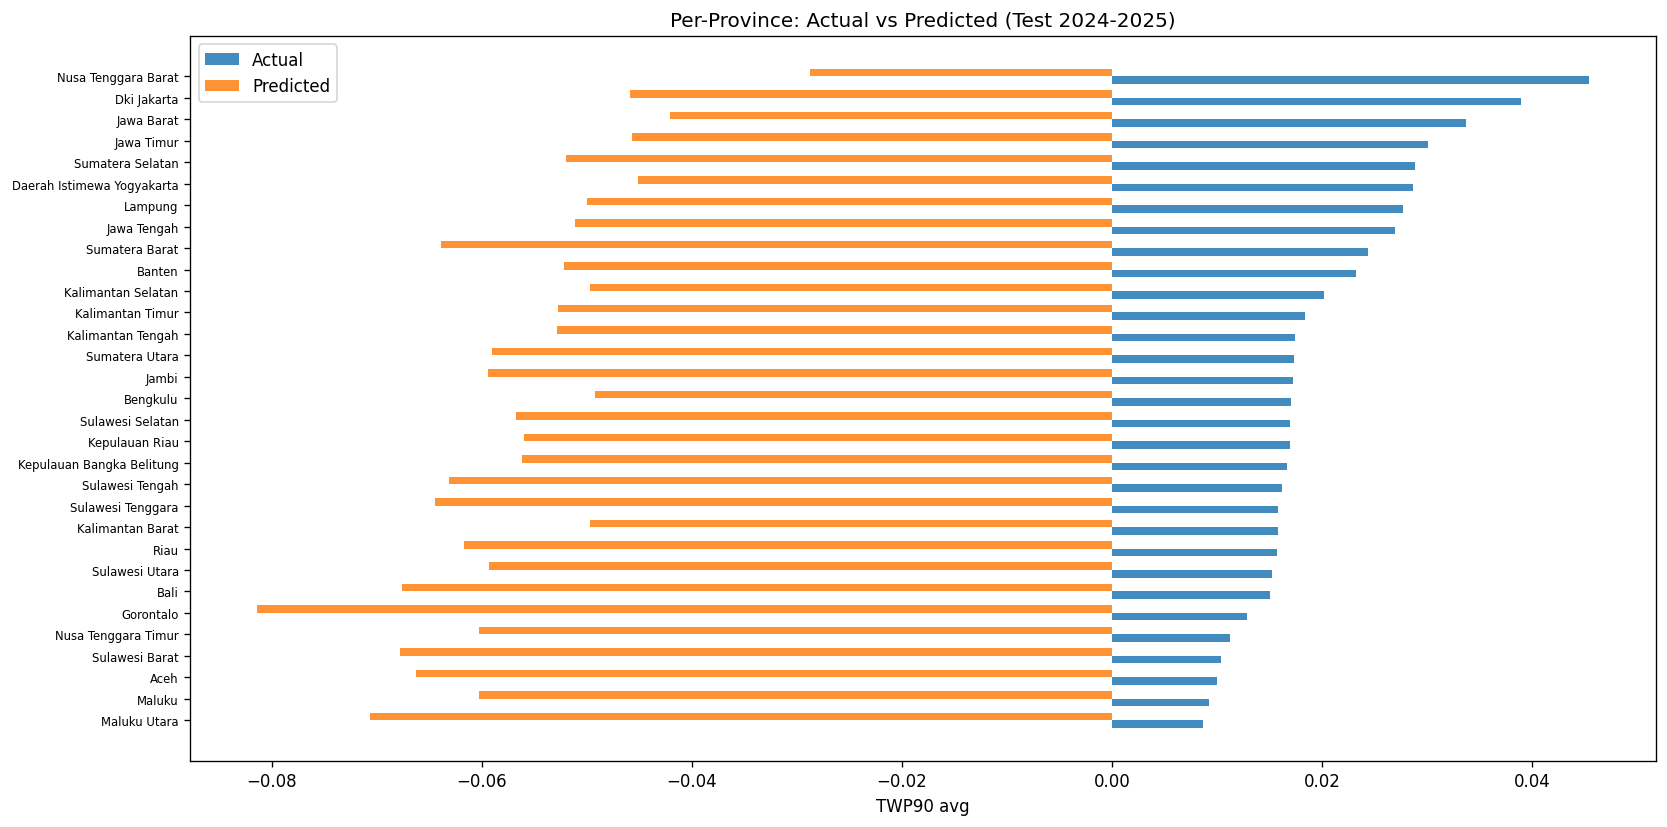

Saved: C:\Users\bimyu\Documents\Projects\DatathonMETC\pipeline_A\output\A2_predictions.csv


In [8]:
# === VISUALISASI 3: Per-Province bar chart ===
test_df_out = df_clean.loc[test_mask, ['provinsi_id', 'nama_provinsi', 'tahun', 'twp90_avg']].copy()
test_df_out['y_pred']  = y_test_pred_np
test_df_out['y_naive'] = y_naive

prov_agg = (test_df_out.groupby('nama_provinsi')
            .agg(actual=('twp90_avg', 'mean'), predicted=('y_pred', 'mean'))
            .sort_values('actual').reset_index())

fig, ax = plt.subplots(figsize=(14, 7))
x_pos = np.arange(len(prov_agg)); w = 0.35
ax.barh(x_pos - w/2, prov_agg['actual'],    w, label='Actual',    alpha=0.85)
ax.barh(x_pos + w/2, prov_agg['predicted'], w, label='Predicted', alpha=0.85)
ax.set_yticks(x_pos); ax.set_yticklabels(prov_agg['nama_provinsi'], fontsize=7)
ax.set_xlabel('TWP90 avg'); ax.set_title('Per-Province: Actual vs Predicted (Test 2024-2025)')
ax.legend(); fig.tight_layout()
fig.savefig(output_dir / 'A2_per_province_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

test_df_out.to_csv(output_dir / 'A2_predictions.csv', index=False)
print(f'Saved: {output_dir / "A2_predictions.csv"}')

In [9]:
# === MODEL 2: Panel FE + AR(1) — tambahkan lagged target ===
ar_col = 'twp90_avg_lag1'
if ar_col in df_clean.columns:
    ar_mask_train = train_mask & df_clean[ar_col].notna()
    ar_mask_test  = test_mask  & df_clean[ar_col].notna()

    X_ar_cols = econ_cols + [ar_col]
    X_ar_full = pd.concat([
        df_clean[X_ar_cols].reset_index(drop=True),
        prov_dummies.reset_index(drop=True),
        year_dummies.reset_index(drop=True)
    ], axis=1).astype(float)
    X_ar_full = sm.add_constant(X_ar_full)

    X_ar_train = X_ar_full[ar_mask_train]
    y_ar_train = y_full[ar_mask_train]
    X_ar_test  = X_ar_full[ar_mask_test]
    y_ar_test  = y_full[ar_mask_test]

    if len(X_ar_train) >= 30:
        model_ar = sm.OLS(y_ar_train, X_ar_train).fit(
            cov_type='cluster',
            cov_kwds={'groups': df_clean.loc[ar_mask_train, 'provinsi_id'].values}
        )
        y_ar_pred = model_ar.predict(X_ar_test)
        m_ar = calc_metrics(y_ar_test, y_ar_pred, 'Panel FE + AR(1) (Test)')

        ar_coef  = model_ar.params.get(ar_col, None)
        ar_pval  = model_ar.pvalues.get(ar_col, None)

        print('=' * 60)
        print('MODEL 2: Panel FE + AR(1)')
        print(f'  RMSE={m_ar["rmse"]:.5f}  MAE={m_ar["mae"]:.5f}  R2={m_ar["r2"]:.4f}')
        print(f'  vs Base RMSE={m_test["rmse"]:.5f}')
        if ar_coef is not None:
            sig = ar_pval < 0.05
            print(f'  twp90_lag1: coeff={ar_coef:.4f}  p={ar_pval:.4f}  {"✅ significant" if sig else "⚠️ not significant"}')
    else:
        print(f'Skipping AR model: insufficient obs ({len(X_ar_train)} < 30)')
else:
    print(f'Column {ar_col} not found — run A1 first to generate lag features')

MODEL 2: Panel FE + AR(1)
  RMSE=0.16315  MAE=0.15885  R2=-328.4412
  vs Base RMSE=0.07836
  twp90_lag1: coeff=0.5332  p=0.5751  ⚠️ not significant


In [10]:
# === FINAL SUMMARY ===
print('\n' + '=' * 70)
print('PIPELINE A — FINAL SUMMARY')
print('=' * 70)
print(f'Data: {df_clean["provinsi_id"].nunique()} prov x {df_clean["tahun"].nunique()} yr = {len(df_clean)} obs')
print(f'Model: Panel OLS (LSDV) — Province + Year Fixed Effects')
print(f'Train: {m_train["n"]} obs | Test: {m_test["n"]} obs')
print(f'\nTest  RMSE={m_test["rmse"]:.5f}  R²={m_test["r2"]:.4f}')
print(f'Naive RMSE={m_naive["rmse"]:.5f}')

sig = coeff_df[coeff_df['significant_5pct']]
print(f'\nSignificant (p<0.05): {len(sig)}/{len(coeff_df)} features')
for _, r in sig.iterrows():
    d = '↑' if r['coefficient'] > 0 else '↓'
    print(f'  {d} {r["feature"]}: coeff={r["coefficient"]:.5f}  p={r["p_value"]:.4f}')

print('\n⚠️  Koefisien = ASOSIASI, bukan kausalitas.')
print('   Causal inference butuh: IV, DiD, atau RCT.')
print('\nOutputs saved to:', output_dir)


PIPELINE A — FINAL SUMMARY
Data: 31 prov x 4 yr = 124 obs
Model: Panel OLS (LSDV) — Province + Year Fixed Effects
Train: 62 obs | Test: 62 obs

Test  RMSE=0.07836  R²=-75.0015
Naive RMSE=0.00557

Significant (p<0.05): 0/8 features

⚠️  Koefisien = ASOSIASI, bukan kausalitas.
   Causal inference butuh: IV, DiD, atau RCT.

Outputs saved to: C:\Users\bimyu\Documents\Projects\DatathonMETC\pipeline_A\output
